# Phase 2: Realistic Speech Task — Input-Layer Perturbation (SHD)

A fraction **f** of every *input* neuron's spikes is relocated to random empty time bins.
Per-neuron spike counts are preserved, so the rate code survives untouched and only spike
timing is destroyed:
- **f = 0** — original spike trains (full temporal code available).
- **f = 1** — timing fully randomised (rate-only input).

This is the **perturbation-aware** protocol: for each f the train / val / test splits are
all regenerated at that perturbation level and a *fresh model is trained from scratch*, so
the curve measures how much class information survives in the perturbed input rather than
how brittle one fixed model is.

Two model variants are compared:
- **SGD-delay** (solid, circles) — SNN with learnable axonal delays.
- **SGD** (dashed, x markers) — baseline SNN without delays.

Three dataset variants:
- **Whole** (blue) — full spike trains (both rate and temporal information).
- **Part** (green) — partial spike trains (reduced rate information).
- **Norm** (red) — rate-normalised spike trains (zero rate information in input).

Source: `shd/shd_train.py`, results in `shd/log/`.

In [1]:
import json
import pathlib
from typing import Optional

import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

SHD_LOG = pathlib.Path("shd/log")  # notebook lives in realistic/

DATASETS = ["whole", "part", "norm"]
DATASET_LABELS = {"whole": "Whole", "part": "Part", "norm": "Norm"}
VARIANTS = [("delay", "SGD-delay"), ("nodelay", "SGD")]

COLORS = {"whole": "#1f77b4", "part": "#2ca02c", "norm": "#d62728"}
LINE_STYLES = {
    "delay": {"marker": "o", "linestyle": "-", "markersize": 5},
    "nodelay": {"marker": "x", "linestyle": "--", "markersize": 6},
}


def results_path(dataset: str, variant: str) -> pathlib.Path:
    """Return the sweep-accuracy JSON path for one dataset/model combination.

    Args:
        dataset: Dataset variant key ("whole", "part" or "norm").
        variant: Model variant key ("delay" or "nodelay").

    Returns:
        Path to the results JSON (which may not exist yet).
    """
    return SHD_LOG / f"shd_{dataset}_{variant}_inputpert_input_perturbation_results.json"


def load_sweep(dataset: str, variant: str) -> Optional[tuple]:
    """Load the final test accuracy at each perturbation fraction.

    Args:
        dataset: Dataset variant key ("whole", "part" or "norm").
        variant: Model variant key ("delay" or "nodelay").

    Returns:
        Tuple of (f values, accuracies in percent), or None when the run has not
        written a results file yet.
    """
    path = results_path(dataset, variant)
    if not path.exists():
        return None
    with open(path) as fh:
        raw = json.load(fh)
    fractions = sorted(float(key) for key in raw)
    accuracies = np.array([raw[f"{f:.1f}"]["accuracy"] for f in fractions]) * 100
    return fractions, accuracies


# Report which combinations are on disk, so the figure below is easy to read.
for dataset in DATASETS:
    for variant, variant_label in VARIANTS:
        status = "found" if results_path(dataset, variant).exists() else "MISSING"
        print(f"{DATASET_LABELS[dataset]:<6} {variant_label:<10} {status}")

Whole  SGD-delay  found
Whole  SGD        found
Part   SGD-delay  found
Part   SGD        found
Norm   SGD-delay  found
Norm   SGD        found


## SHD — Accuracy vs Input Perturbation

Each point is a separate model trained *and* tested at that perturbation level. A steeper
drop indicates a stronger reliance on input spike timing; a flat curve indicates the model
solves the task from the rate code alone, which survives the perturbation by construction.

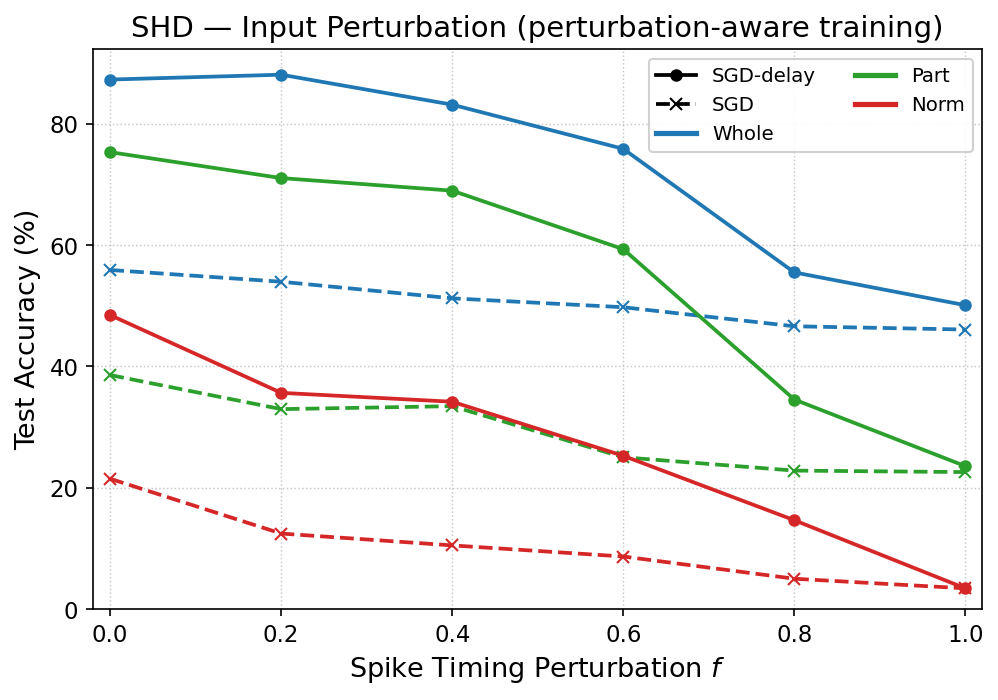

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 4.8))

missing_runs = []
for dataset in DATASETS:
    for variant, variant_label in VARIANTS:
        sweep = load_sweep(dataset, variant)
        if sweep is None:
            missing_runs.append(f"{DATASET_LABELS[dataset]} x {variant_label}")
            continue
        fractions, accuracies = sweep
        ax.plot(
            fractions, accuracies,
            color=COLORS[dataset], linewidth=1.8, **LINE_STYLES[variant],
        )

ax.set_title("SHD — Input Perturbation (perturbation-aware training)")
ax.set_xlabel("Spike Timing Perturbation $f$")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, None)
ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

# ---------- legend ----------
handles = [
    mlines.Line2D([], [], color="black", linewidth=1.8, label=variant_label,
                  **LINE_STYLES[variant])
    for variant, variant_label in VARIANTS
]
handles += [
    mlines.Line2D([], [], color=COLORS[dataset], linewidth=2.5,
                  label=DATASET_LABELS[dataset])
    for dataset in DATASETS
]
ax.legend(handles=handles, loc="upper right", framealpha=0.9, ncol=2)

if missing_runs:
    ax.text(
        0.02, 0.02,
        "Not available yet (placeholder):\n" + "\n".join(missing_runs),
        transform=ax.transAxes, ha="left", va="bottom", fontsize=9,
        color="0.35",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="0.94", edgecolor="0.75"),
    )

fig.tight_layout()
#plt.savefig("shd_input_perturbation.png", dpi=300, bbox_inches="tight")
plt.show()